# Trading Execution Model for S&P 500 ETF (SPY)

This notebook explores advanced execution algorithms for trading the S&P 500 ETF (SPY). We'll implement and analyze various execution strategies designed to minimize market impact and transaction costs while executing large orders efficiently.

In this notebook, we'll cover:

1. Market microstructure fundamentals
2. Implementation shortfall analysis
3. VWAP, TWAP, and POV execution algorithms
4. Adaptive execution strategies
5. Market impact modeling
6. Performance evaluation of execution strategies

## Setup and Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from datetime import datetime, timedelta
import pytz
import warnings

# Suppress warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['font.size'] = 12

# Set random seed for reproducibility
np.random.seed(42)

## Fetching S&P 500 ETF Data

We'll start by downloading historical data for SPY, including both daily and intraday data.

In [2]:
# Download daily SPY data for the last 3 months
spy_daily = yf.download('SPY', period='3mo', auto_adjust=False)

# Display basic information
print(f"SPY Daily Data: {spy_daily.index.min().date()} to {spy_daily.index.max().date()}")
print(f"Number of trading days: {len(spy_daily)}")
spy_daily.head()

[*********************100%***********************]  1 of 1 completed

SPY Daily Data: 2025-02-03 to 2025-05-02
Number of trading days: 63


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY,SPY
Date,,,,,,
2025-02-03,595.977173,597.770020,600.289978,590.489990,592.669983,65857200
2025-02-04,599.975159,601.780029,602.299988,597.280029,597.830017,33457800
2025-02-05,602.407776,604.219971,604.369995,598.580017,600.640015,30653100
2025-02-06,604.501526,606.320007,606.450012,602.630005,605.989990,35771500
2025-02-07,598.968201,600.770020,608.130005,600.049988,606.890015,50788500


In [3]:
# Download SPY intraday data (1-minute bars) for a recent day
# Note: Yahoo Finance has limitations on intraday data; adjust the date as needed
end_date = spy_daily.index[-1]
start_date = end_date - timedelta(days=7)  # One week of intraday data
spy_intraday = yf.download('SPY', start=start_date, end=end_date, interval='1m')

# Display basic information
print(f"SPY Intraday Data: {spy_intraday.index.min()} to {spy_intraday.index.max()}")
print(f"Number of 1-minute bars: {len(spy_intraday)}")
spy_intraday.head()

[*********************100%***********************]  1 of 1 completed

YF.download() has changed argument auto_adjust default to True
SPY Intraday Data: 2025-04-25 13:30:00+00:00 to 2025-05-01 19:59:00+00:00
Number of 1-minute bars: 1940


Price,Close,High,Low,Open,Volume
Ticker,SPY,SPY,SPY,SPY,SPY
Datetime,,,,,
2025-04-25 13:30:00+00:00,547.059998,547.489990,546.539978,546.650024,2536167
2025-04-25 13:31:00+00:00,546.570007,547.190002,546.390015,547.030029,204955
2025-04-25 13:32:00+00:00,545.750000,546.580017,545.650024,546.559998,252087
2025-04-25 13:33:00+00:00,546.899902,546.919983,545.799988,545.799988,205338
2025-04-25 13:34:00+00:00,546.900024,547.049988,546.640015,546.909973,127850


Let's plot the daily and intraday price data to get a sense of the market activity.

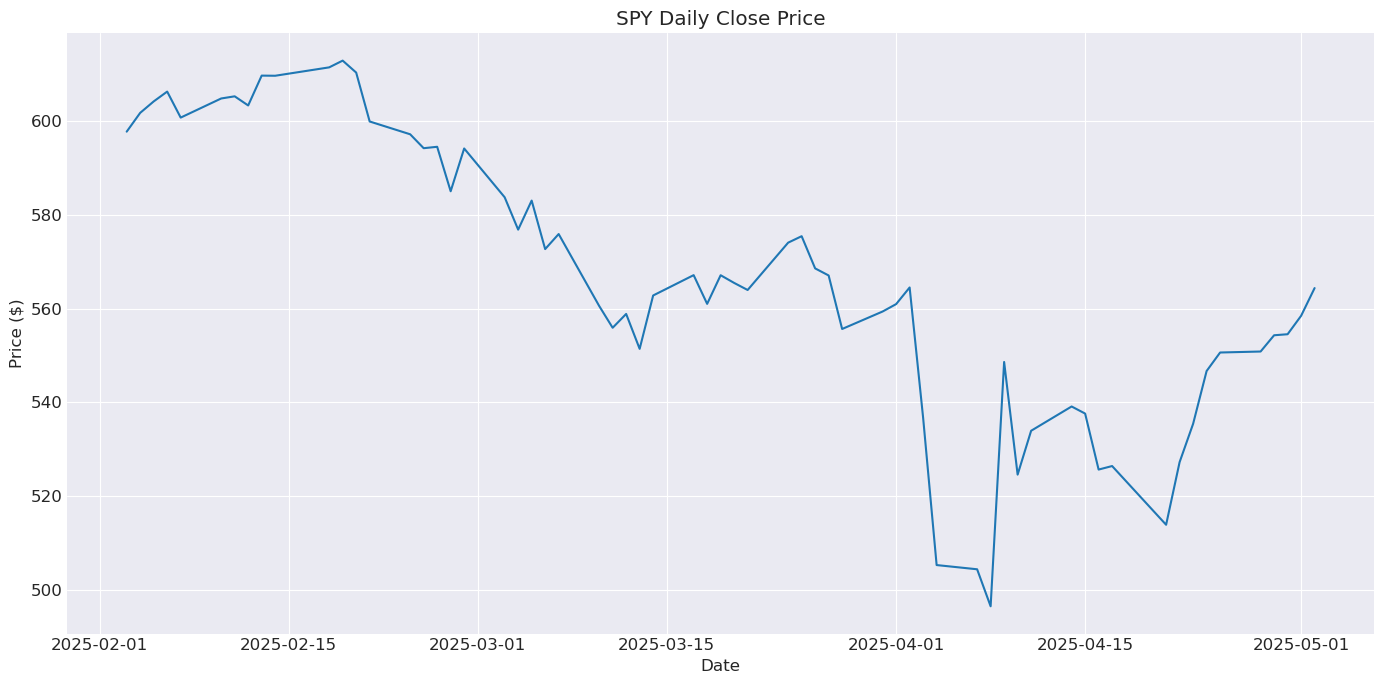

In [4]:
# Plot daily SPY price
plt.figure(figsize=(14, 7))
plt.plot(spy_daily.index, spy_daily['Close'])
plt.title('SPY Daily Close Price')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

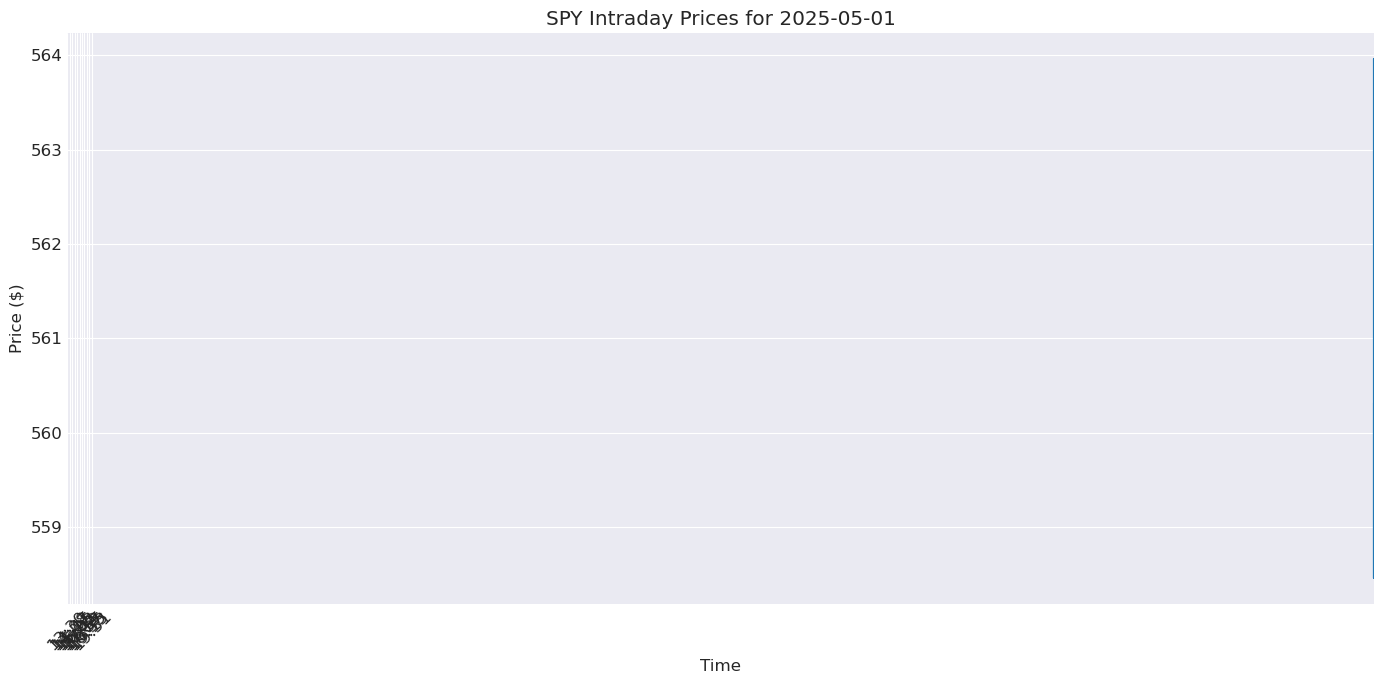

In [5]:
# Plot intraday SPY price for the most recent day
last_day = spy_intraday.index.date[-1]
last_day_data = spy_intraday[spy_intraday.index.date == last_day]

plt.figure(figsize=(14, 7))
# Convert time objects to formatted strings for plotting
time_strings = [t.strftime('%H:%M') for t in last_day_data.index.time]

# Plot using positional indices and add x-tick labels
plt.plot(last_day_data['Close'])
plt.title(f'SPY Intraday Prices for {last_day}')
plt.xlabel('Time')
plt.ylabel('Price ($)')

# Add time labels at regular intervals
tick_positions = range(0, len(time_strings), len(time_strings)//10)
plt.xticks(tick_positions, [time_strings[i] for i in tick_positions], rotation=45)

plt.grid(True)
plt.tight_layout()
plt.show()

## Intraday Volume Profile Analysis

Understanding the typical intraday volume profile is essential for designing effective execution algorithms. Let's analyze the average volume by time of day across our data.

In [8]:
# Analyze volume distribution throughout the trading day
def analyze_volume_profile(intraday_data):
    # Convert index to Eastern Time (market time zone)
    eastern = pytz.timezone('US/Eastern')
    if intraday_data.index.tz is None:
        intraday_data.index = intraday_data.index.tz_localize('UTC').tz_convert(eastern)
    elif intraday_data.index.tz != eastern:
        intraday_data.index = intraday_data.index.tz_convert(eastern)
    
    # Create hour and minute columns
    intraday_data['Hour'] = intraday_data.index.hour
    intraday_data['Minute'] = intraday_data.index.minute
    intraday_data['TimeOfDay'] = intraday_data.index.strftime('%H:%M')
    intraday_data['Date'] = intraday_data.index.date
    
    # Group by time of day and calculate average volume
    volume_profile = intraday_data.groupby('TimeOfDay')['Volume'].mean().reset_index()
    
    # Convert TimeOfDay to datetime for proper sorting
    volume_profile['TimeObj'] = pd.to_datetime(volume_profile['TimeOfDay']).dt.time
    volume_profile = volume_profile.sort_values('TimeObj')
    
    # Calculate cumulative volume percentage
    total_volume = volume_profile['Volume'].sum()
    volume_profile['Cumulative_Pct'] = volume_profile['Volume'].cumsum() / total_volume * 100

    # Calculate volume percentage from the volume data
    volume_profile['Volume_Pct'] = volume_profile['Volume'] / total_volume * 100    
    
    return volume_profile

# Calculate volume profile
volume_profile = analyze_volume_profile(spy_intraday)

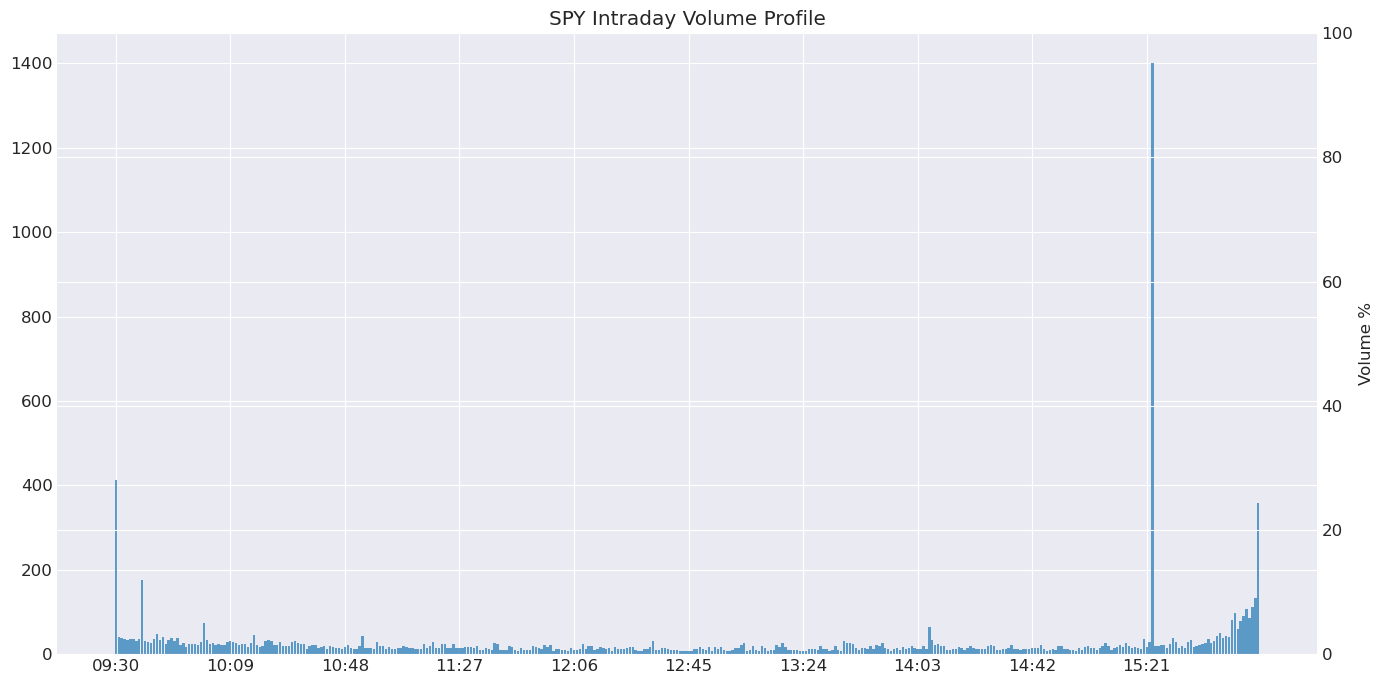

In [9]:
# Plot volume profile
plt.figure(figsize=(14, 7))

# Bar chart for average volume 
plt.bar(range(len(volume_profile)), volume_profile['Volume_Pct'] * 100, alpha=0.7)

# Add cumulative percentage line
ax2 = plt.twinx()
ax2.plot(range(len(volume_profile)), volume_profile['Cumulative_Pct'] * 100, 'r-', linewidth=2)
ax2.set_ylabel('Cumulative Volume %')
ax2.set_ylim([0, 100])

# Set x-axis labels
step = max(1, len(volume_profile) // 10)  # Limit to ~10 labels
plt.xticks(range(0, len(volume_profile), step), 
           volume_profile['TimeOfDay'].iloc[::step].values, rotation=45)

plt.title('SPY Intraday Volume Profile')
plt.xlabel('Time of Day (ET)')
plt.ylabel('Volume %')
plt.grid(True)
plt.tight_layout()
plt.show()

## Market Impact Modeling

Market impact refers to the effect that a market participant's trading activity has on the price of an asset. Let's implement a simple market impact model to estimate the price impact of large orders.

In [102]:
import math


def square_root_impact_model(order_size, adn, volatility, price, participation_rate=0.1):
    """
    Square-root impact model to estimate market impact of a large order
    
    Parameters:
    order_size: Number of shares to execute
    adn: Average daily volume (number of shares)
    volatility: Daily volatility (decimal)
    price: Current asset price
    participation_rate: Target participation rate (decimal)
    
    Returns:
    Estimated market impact (in price units)
    """
    # Convert inputs to float to ensure compatibility
    order_size = float(order_size)
    if isinstance(adn, pd.Series):
        adn = float(adn.iloc[0])
    else:
        adn = float(adn)
        
    if isinstance(volatility, pd.Series):
        volatility = float(volatility.iloc[0])
    else:
        volatility = float(volatility)
        
    if isinstance(price, pd.Series):
        price = float(price.iloc[0])
    else:
        price = float(price)
    
    # Normalize order size as percentage of ADV
    normalized_size = order_size / adn
    
    # Calculate execution time in days based on participation rate
    exec_time = order_size / (adn * participation_rate)
    
    # Calculate impact using square-root formula
    # Typical value for constant is 0.1
    impact_constant = 0.1
    impact_pct = impact_constant * volatility * math.sqrt(normalized_size / exec_time)
    
    # Convert to price units
    impact_price = impact_pct * price
    
    return impact_price

# Linear impact model 
def linear_impact_model(order_size, adn, price, impact_factor=0.1):
    """
    Linear impact model to estimate market impact of a trade
    
    Parameters:
    order_size: Number of shares in the order
    adn: Average daily volume (shares)
    price: Asset price
    impact_factor: Impact coefficient (higher = more impact)
    
    Returns:
    Estimated price impact
    """
    # Calculate impact as a linear function of order size relative to ADV
    impact_pct = impact_factor * (order_size / adn)
    impact_price = impact_pct * price
    
    return impact_price

In [103]:
# Example: Estimate market impact for different order sizes
# Calculate ADV (Average Daily Volume)
adv = spy_daily['Volume'].mean()
# Extract the numeric value from the Series if adv is a Series
if isinstance(adv, pd.Series):
    adv = adv.iloc[0]
print(f"SPY Average Daily Volume: {adv:,.0f} shares")

# Calculate daily volatility
daily_returns = spy_daily['Close'].pct_change().dropna()
daily_volatility = daily_returns.std()
# Convert daily_volatility to scalar if it's a Series
if isinstance(daily_volatility, pd.Series):
    daily_volatility = daily_volatility.iloc[0]
print(f"SPY Daily Volatility: {daily_volatility:.4f}")

# Current price
current_price = spy_daily['Close'].iloc[-1]
# Convert current_price to scalar if it's a Series
if isinstance(current_price, pd.Series):
    current_price = current_price.iloc[0]
print(f"SPY Current Price: ${current_price:.2f}")

# Test different order sizes
order_sizes = [10000, 50000, 100000, 500000, 1000000]
participation_rates = [0.05, 0.1, 0.2, 0.3]

# Calculate impact for different order sizes and participation rates
impact_results = []
for order_size in order_sizes:
    for participation_rate in participation_rates:
        # Square root model impact
        sqrt_impact = square_root_impact_model(
            order_size, adv, daily_volatility, current_price, participation_rate)
        
        # Linear model impact
        linear_impact = linear_impact_model(order_size, adv, current_price)
        
        # Store results
        impact_results.append({
            'Order Size': order_size,
            'Order Size (% of ADV)': order_size / adv * 100,
            'Participation Rate': participation_rate * 100,
            'Execution Time (days)': order_size / (adv * participation_rate),
            'Square Root Impact ($)': sqrt_impact,
            'Square Root Impact (bps)': sqrt_impact / current_price * 10000,
            'Linear Impact ($)': linear_impact,
            'Linear Impact (bps)': linear_impact / current_price * 10000
        })

# Convert to DataFrame
impact_df = pd.DataFrame(impact_results)

# Display impact table
display(impact_df[['Order Size', 'Order Size (% of ADV)', 'Participation Rate', 
                   'Execution Time (days)', 'Square Root Impact (bps)', 'Linear Impact (bps)']])

SPY Average Daily Volume: 74,173,674 shares
SPY Daily Volatility: 0.0210
SPY Current Price: $564.39


,Order Size,Order Size (% of ADV),Participation Rate,Execution Time (days),Square Root Impact (bps),Linear Impact (bps)
0,10000,0.013482,5.0,0.002696,4.697319,0.134819
1,10000,0.013482,10.0,0.001348,6.643013,0.134819
2,10000,0.013482,20.0,0.000674,9.394638,0.134819
3,10000,0.013482,30.0,0.000449,11.506035,0.134819
4,50000,0.067409,5.0,0.013482,4.697319,0.674094
5,50000,0.067409,10.0,0.006741,6.643013,0.674094
6,50000,0.067409,20.0,0.003370,9.394638,0.674094
7,50000,0.067409,30.0,0.002247,11.506035,0.674094
8,100000,0.134819,5.0,0.026964,4.697319,1.348187
9,100000,0.134819,10.0,0.013482,6.643013,1.348187


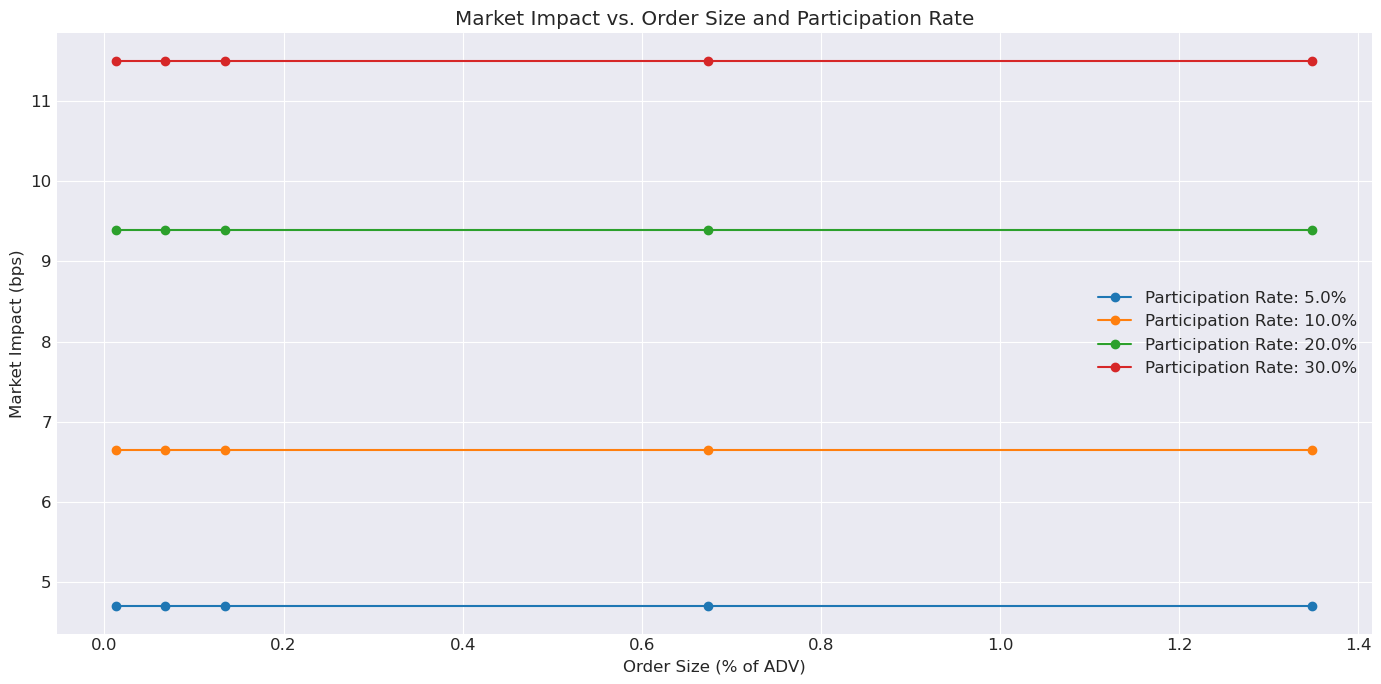

In [104]:
# Visualize market impact vs. order size and participation rate
plt.figure(figsize=(14, 7))

for rate in impact_df['Participation Rate'].unique():
    subset = impact_df[impact_df['Participation Rate'] == rate]
    plt.plot(subset['Order Size (% of ADV)'], subset['Square Root Impact (bps)'], 
             marker='o', label=f"Participation Rate: {rate}%")

plt.title('Market Impact vs. Order Size and Participation Rate')
plt.xlabel('Order Size (% of ADV)')
plt.ylabel('Market Impact (bps)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Trading Execution Algorithms

Now, let's implement some popular execution algorithms:

1. **TWAP** (Time-Weighted Average Price) - Executes evenly over time
2. **VWAP** (Volume-Weighted Average Price) - Executes proportionally to expected volume
3. **POV** (Percentage of Volume) - Executes as a percentage of market volume
4. **Adaptive** - Adjusts execution based on market conditions

In [105]:
def generate_historical_volume_profile(intraday_data):
    """
    Generate a historical volume profile by time of day, 
    averaging across all available days of data
    """
    # Create a copy to avoid modifying the original data
    data = intraday_data.copy()
    
    # Ensure timezone is set to Eastern
    eastern = pytz.timezone('US/Eastern')
    if data.index.tz is None:
        data.index = data.index.tz_localize('UTC').tz_convert(eastern)
    elif data.index.tz != eastern:
        data.index = data.index.tz_convert(eastern)
    
    # Extract time components
    data['Hour'] = data.index.hour
    data['Minute'] = data.index.minute
    data['TimeOfDay'] = data.index.strftime('%H:%M')
    data['Date'] = data.index.date
    
    # Get unique dates in the data
    dates = data['Date'].unique()
    
    # Create volume profiles for each day
    daily_profiles = []
    
    for date in dates:
        day_data = data[data['Date'] == date]
        if len(day_data) > 0:  # Ensure we have data for this day
            daily_volume = day_data.groupby('TimeOfDay')['Volume'].sum().reset_index()
            daily_volume['Date'] = date
            daily_profiles.append(daily_volume)
    
    # Combine daily profiles
    all_profiles = pd.concat(daily_profiles)
    
    # Calculate average volume by time of day across all days
    avg_profile = all_profiles.groupby('TimeOfDay')['Volume'].mean().reset_index()
    
    # Calculate volume distribution as percentage of daily total
    total_volume = avg_profile['Volume'].sum()
    avg_profile['Volume_Pct'] = avg_profile['Volume'] / total_volume
    
    # Convert TimeOfDay to datetime for proper sorting
    avg_profile['TimeObj'] = pd.to_datetime(avg_profile['TimeOfDay']).dt.time
    avg_profile = avg_profile.sort_values('TimeObj')
    
    # Calculate cumulative percentage
    avg_profile['Cumulative_Pct'] = avg_profile['Volume_Pct'].cumsum()
    
    return avg_profile

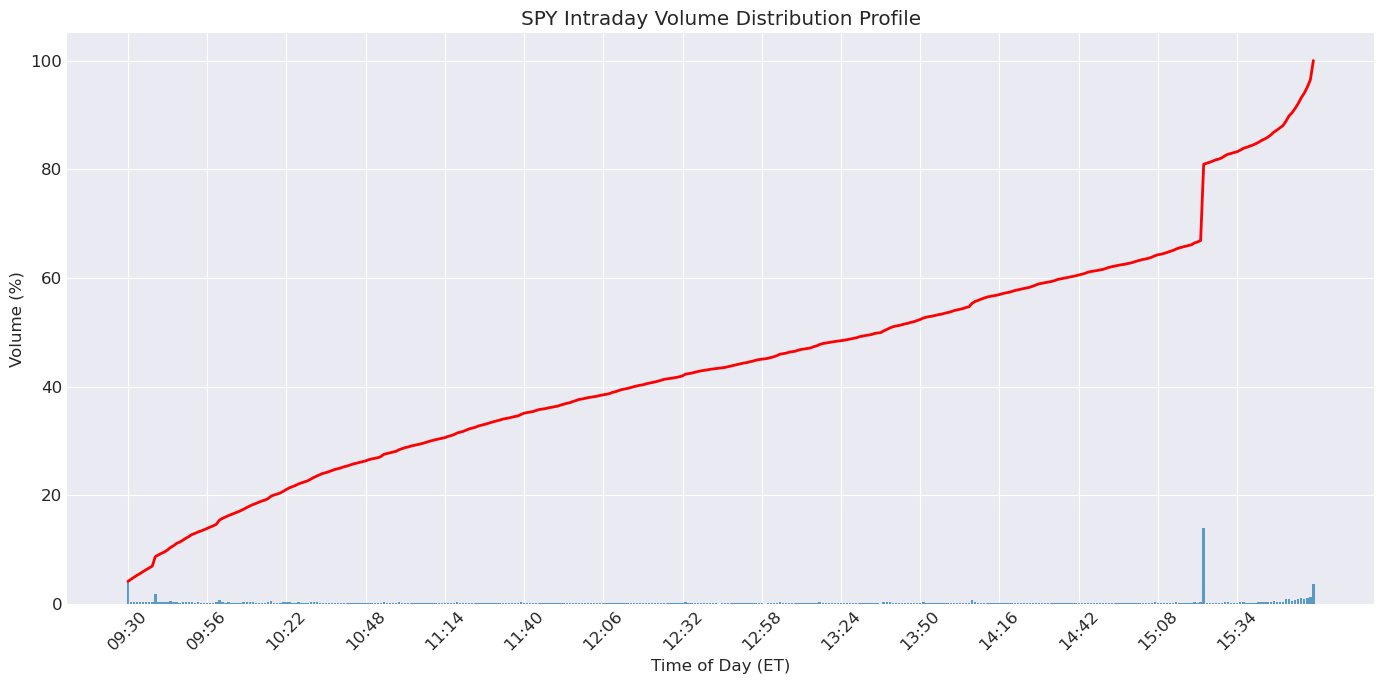

In [106]:
# Generate volume profile
volume_profile = generate_historical_volume_profile(spy_intraday)

# Plot volume profile
plt.figure(figsize=(14, 7))
plt.bar(range(len(volume_profile)), volume_profile['Volume_Pct'] * 100, alpha=0.7)
plt.plot(range(len(volume_profile)), volume_profile['Cumulative_Pct'] * 100, 'r-', linewidth=2)

# Set x-axis labels
step = max(1, len(volume_profile) // 15)  # Limit to ~15 labels
plt.xticks(range(0, len(volume_profile), step), 
           volume_profile['TimeOfDay'].iloc[::step], rotation=45)

plt.title('SPY Intraday Volume Distribution Profile')
plt.xlabel('Time of Day (ET)')
plt.ylabel('Volume (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [107]:
def twap_execution(order_size, start_time, end_time, intervals=20):
    """
    Generate a TWAP execution schedule
    
    Parameters:
    order_size: Total number of shares to execute
    start_time: Starting time for execution window
    end_time: Ending time for execution window
    intervals: Number of execution intervals
    
    Returns:
    DataFrame with execution schedule
    """
    # Calculate time delta between intervals
    total_seconds = (end_time - start_time).total_seconds()
    interval_seconds = total_seconds / intervals
    
    # Calculate shares per interval
    shares_per_interval = order_size / intervals
    
    # Generate execution schedule
    schedule = []
    for i in range(intervals):
        execution_time = start_time + timedelta(seconds=i * interval_seconds)
        schedule.append({
            'Interval': i + 1,
            'Time': execution_time,
            'Shares': shares_per_interval,
            'Percent_of_Order': 100 / intervals
        })
    
    return pd.DataFrame(schedule)

def vwap_execution(order_size, volume_profile, trading_day_date):
    """
    Generate a VWAP execution schedule
    
    Parameters:
    order_size: Total number of shares to execute
    volume_profile: Historical volume profile by time of day
    trading_day_date: Date of trading day
    
    Returns:
    DataFrame with execution schedule
    """
    schedule = []
    for i, row in volume_profile.iterrows():        
        time_str = row['TimeOfDay'].values[0]
        volume_pct = row['Volume_Pct']
        # Parse time and combine with trading day date
        try:
            hour, minute = map(int, str(time_str).strip().split(':'))
        except ValueError:
            # Handle the case where time_str might have unexpected format
            if 'Ticker' in str(time_str):
                clean_time = str(time_str).split('\n')[-1].strip()
                hour, minute = map(int, clean_time.split(':'))
            else:
                # If still can't parse, use default values
                hour, minute = 9, 30
        execution_time = datetime.combine(trading_day_date, datetime.min.time().replace(hour=hour, minute=minute))
        
        # Calculate shares for this interval
        shares = order_size * volume_pct
        
        schedule.append({
            'Interval': i + 1,
            'Time': execution_time,
            'Shares': shares,
            'Percent_of_Order': volume_pct * 100
        })
    
    return pd.DataFrame(schedule)

def pov_execution(order_size, volume_profile, participation_rate, trading_day_date):
    """
    Generate a Percentage of Volume (POV) execution schedule
    
    Parameters:
    order_size: Total number of shares to execute
    volume_profile: Historical volume profile by time of day
    participation_rate: Target participation rate (decimal)
    trading_day_date: Date of trading day
    
    Returns:
    DataFrame with execution schedule
    """
    # Assuming volume_profile has expected volume for each interval
    schedule = []
    executed_shares = 0    
    for i, row in volume_profile.iterrows():        
        time_str = row['TimeOfDay'].values[0]
        volume_pct = row['Volume_Pct'].values[0]
        # Calculate expected market volume for this interval (as a percent of order size)
        expected_volume = order_size / participation_rate * volume_pct
        
        # Calculate shares to execute this interval
        interval_shares = min(expected_volume * participation_rate, order_size - executed_shares)
        
        if interval_shares <= 0:
            continue  # Skip if no shares to execute
        
        # Parse time and combine with trading day date
        try:
            hour, minute = map(int, str(time_str).split(':'))
            execution_time = datetime.combine(trading_day_date, datetime.min.time().replace(hour=hour, minute=minute))
            
            # Update schedule
            schedule.append({
                'Interval': i + 1,
                'Time': execution_time,
                'Shares': interval_shares,
                'Percent_of_Order': interval_shares / order_size * 100,
                'Executed_Total': executed_shares + interval_shares
            })
            
            executed_shares += interval_shares
            
            # Break if order is fully executed
            if executed_shares >= order_size:
                break
        except (ValueError, AttributeError) as e:
            # In case of parsing error, skip this interval
            print(f"Error parsing time {time_str} at interval {i+1}: {e}")
            continue
    
    return pd.DataFrame(schedule)

In [108]:
# Example: Create execution schedules for a 100,000 share order
# Parameters
order_size = 100000
trading_day = datetime.today().date()
market_open = datetime.combine(trading_day, datetime.min.time().replace(hour=9, minute=30))
market_close = datetime.combine(trading_day, datetime.min.time().replace(hour=16, minute=0))

# Generate execution schedules
twap_schedule = twap_execution(order_size, market_open, market_close, intervals=30)
vwap_schedule = vwap_execution(order_size, volume_profile, trading_day)
pov_schedule = pov_execution(order_size, volume_profile, participation_rate=0.1, trading_day_date=trading_day)

# Display sample of each schedule
print("TWAP Execution Schedule (Sample):")
display(twap_schedule.head())

print("\nVWAP Execution Schedule (Sample):")
display(vwap_schedule.head())

print("\nPOV Execution Schedule (Sample):")
display(pov_schedule.head())

TWAP Execution Schedule (Sample):


,Interval,Time,Shares,Percent_of_Order
0,1,2025-05-02 09:30:00,3333.333333,3.333333
1,2,2025-05-02 09:43:00,3333.333333,3.333333
2,3,2025-05-02 09:56:00,3333.333333,3.333333
3,4,2025-05-02 10:09:00,3333.333333,3.333333
4,5,2025-05-02 10:22:00,3333.333333,3.333333



VWAP Execution Schedule (Sample):


,Interval,Time,Shares,Percent_of_Order
0,1,2025-05-02 09:30:00,"Ticker 4124.346786 Name: 0, dtype: object","Ticker 4.124347 Name: 0, dtype: object"
1,2,2025-05-02 09:31:00,"Ticker 401.675747 Name: 1, dtype: object","Ticker 0.401676 Name: 1, dtype: object"
2,3,2025-05-02 09:32:00,"Ticker 376.635709 Name: 2, dtype: object","Ticker 0.376636 Name: 2, dtype: object"
3,4,2025-05-02 09:33:00,"Ticker 353.754685 Name: 3, dtype: object","Ticker 0.353755 Name: 3, dtype: object"
4,5,2025-05-02 09:34:00,"Ticker 328.256789 Name: 4, dtype: object","Ticker 0.328257 Name: 4, dtype: object"



POV Execution Schedule (Sample):


,Interval,Time,Shares,Percent_of_Order,Executed_Total
0,1,2025-05-02 09:30:00,4124.346786,4.124347,4124.346786
1,2,2025-05-02 09:31:00,401.675747,0.401676,4526.022533
2,3,2025-05-02 09:32:00,376.635709,0.376636,4902.658242
3,4,2025-05-02 09:33:00,353.754685,0.353755,5256.412927
4,5,2025-05-02 09:34:00,328.256789,0.328257,5584.669716


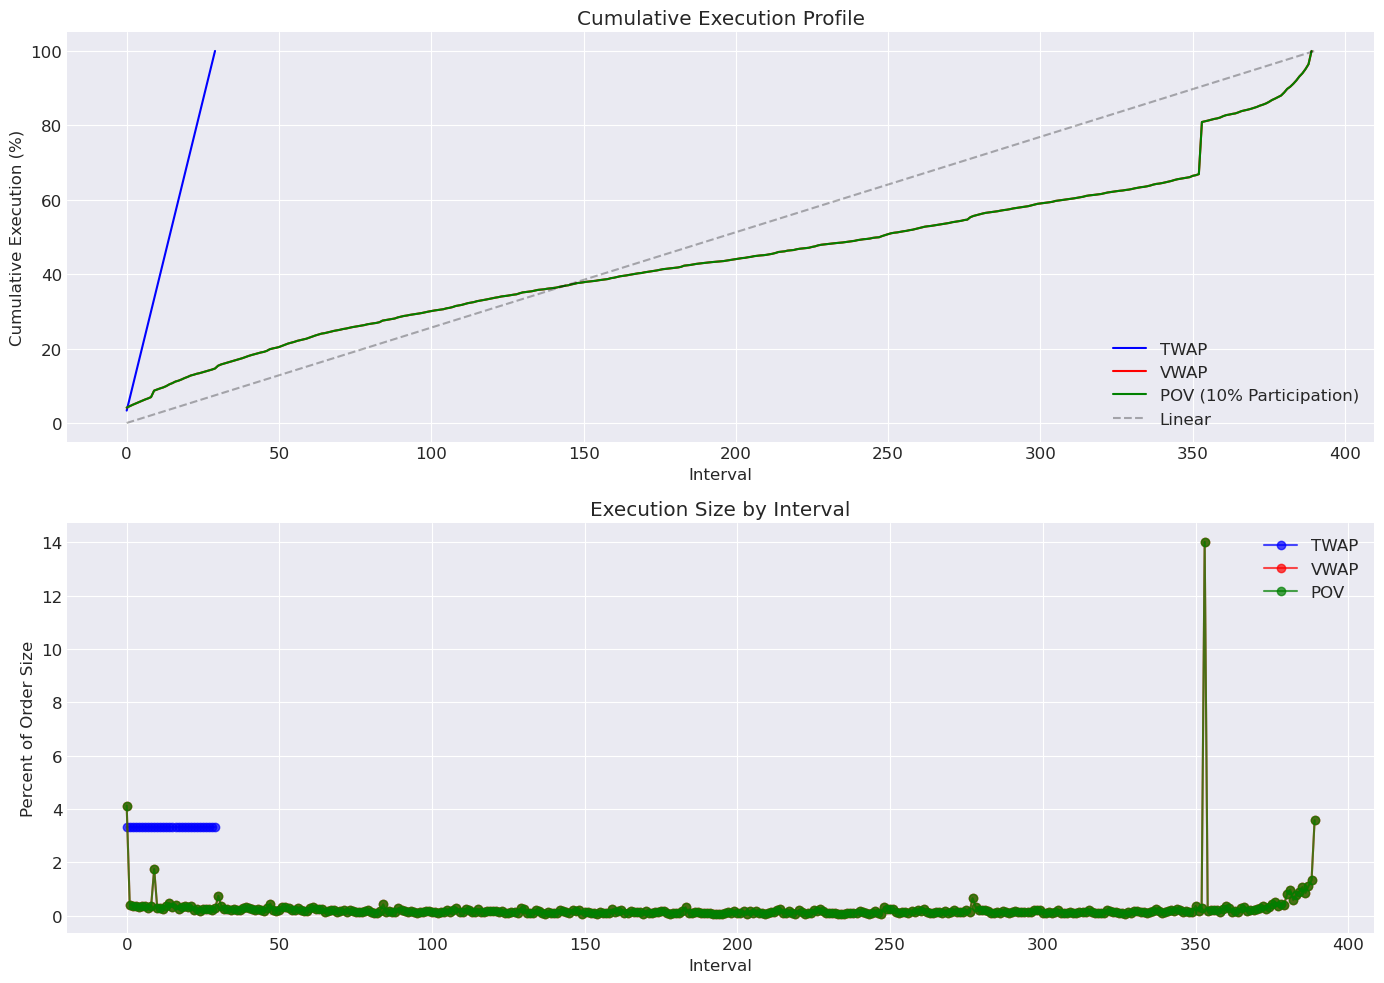

In [109]:
# Visualize execution schedules
plt.figure(figsize=(14, 10))

# Cumulative execution
plt.subplot(2, 1, 1)

# TWAP
twap_cum = twap_schedule['Shares'].cumsum() / order_size * 100
plt.plot(range(len(twap_cum)), twap_cum, 'b-', label='TWAP')

# VWAP
vwap_cum = vwap_schedule['Shares'].cumsum() / order_size * 100
plt.plot(range(len(vwap_cum)), vwap_cum, 'r-', label='VWAP')

# POV
if not pov_schedule.empty:
    pov_cum = pov_schedule['Shares'].cumsum() / order_size * 100
    plt.plot(range(len(pov_cum)), pov_cum, 'g-', label='POV (10% Participation)')

# Reference diagonal line (linear execution)
plt.plot([0, max(len(twap_cum), len(vwap_cum))], 
         [0, 100], 'k--', alpha=0.3, label='Linear')

plt.title('Cumulative Execution Profile')
plt.xlabel('Interval')
plt.ylabel('Cumulative Execution (%)')
plt.legend()
plt.grid(True)

# Execution by interval
plt.subplot(2, 1, 2)

# TWAP
plt.plot(range(len(twap_schedule)), twap_schedule['Percent_of_Order'], 'bo-', alpha=0.7, label='TWAP')

# VWAP
plt.plot(range(len(vwap_schedule)), vwap_schedule['Percent_of_Order'], 'ro-', alpha=0.7, label='VWAP')

# POV
if not pov_schedule.empty:
    plt.plot(range(len(pov_schedule)), pov_schedule['Percent_of_Order'], 'go-', alpha=0.7, label='POV')

plt.title('Execution Size by Interval')
plt.xlabel('Interval')
plt.ylabel('Percent of Order Size')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Implementation Shortfall Analysis

Implementation shortfall is the difference between the decision price (when the trading decision was made) and the actual execution price. Let's create a simulation to estimate the implementation shortfall for different execution strategies.

In [110]:
import math
import numpy as np

def simulate_execution_with_impact(schedule, initial_price, daily_volatility, market_trend=0, impact_function=None):
    """
    Simulate execution with market impact, volatility, and market trend
    
    Parameters:
    schedule: Execution schedule DataFrame
    initial_price: Starting price
    daily_volatility: Daily volatility (decimal)
    market_trend: Expected daily return (decimal)
    impact_function: Function to calculate market impact
    
    Returns:
    DataFrame with execution details including prices and costs
    """
    simulation = schedule.copy()
    
    # Calculate time intervals in days (from start of execution)
    if 'Time' in simulation.columns:
        start_time = simulation['Time'].min()
        simulation['Time_in_Days'] = [(t - start_time).days for t in simulation['Time']]
        #[(t - start_time).total_seconds() / (24 * 3600) for t in simulation['Time']]
    else:
        # If no time column, use intervals
        intervals = len(simulation)
        simulation['Time_in_Days'] = [i / intervals for i in range(intervals)]
    
    # Initialize price series
    simulation['Market_Price'] = initial_price
    simulation['Execution_Price'] = initial_price
    simulation['Impact'] = 0.0  # Initialize the Impact column
    
    # Preprocessing
    total_shares = simulation['Shares'].sum()
    executed_shares = 0
    cumulative_impact = 0  # Persistent impact
    
    # Simulate execution
    for i, row in simulation.iterrows():
        time_in_days = row['Time_in_Days']
        shares = row['Shares']        
        # Calculate market price based on time
        price_drift = initial_price * market_trend * time_in_days  # Deterministic drift
        price_random = initial_price * daily_volatility * np.sqrt(int(time_in_days)) * np.random.normal()  # Random component
        market_price = initial_price + price_drift + price_random
        
        # Calculate market impact
        if impact_function is not None:
            # Calculate temporary impact for this trade
            temp_impact = impact_function(shares, total_shares * 10, daily_volatility, market_price)
            
            # Persistent impact from previous trades (simplified model)
            execution_price = market_price + temp_impact + cumulative_impact
            
            # Update cumulative impact (decay model)
            # Assuming 1/2 of impact is permanent
            cumulative_impact += temp_impact * 0.5
        else:
            # No impact model - execution at market price
            execution_price = market_price
        
        # Update simulation
        simulation.at[i, 'Market_Price'] = market_price
        simulation.at[i, 'Execution_Price'] = execution_price
        simulation.at[i, 'Impact'] = execution_price - market_price
        
        executed_shares += shares
    
    # Calculate execution statistics
    simulation['Cost'] = simulation['Shares'] * simulation['Execution_Price']
    simulation['Market_Value'] = simulation['Shares'] * simulation['Market_Price']
    simulation['Slippage'] = simulation['Cost'] - simulation['Market_Value']
    
    # Calculate VWAP
    vwap = simulation['Cost'].sum() / simulation['Shares'].sum()
    implementation_shortfall = vwap - initial_price
    implementation_shortfall_bps = implementation_shortfall / initial_price * 10000
    
    # Add summary statistics
    summary = {
        'Initial Price': initial_price,
        'VWAP': vwap,
        'Implementation Shortfall': implementation_shortfall,
        'Implementation Shortfall (bps)': implementation_shortfall_bps,
        'Total Cost': simulation['Cost'].sum(),
        'Total Market Value': simulation['Market_Value'].sum(),
        'Total Slippage': simulation['Slippage'].sum(),
        'Slippage (bps)': simulation['Slippage'].sum() / (initial_price * total_shares) * 10000
    }
    
    return simulation, summary

In [111]:
# Parameters for simulation
initial_price = spy_daily['Close'].iloc[-1]
daily_volatility = spy_daily['Close'].pct_change().std()
market_trend = 0.0  # Assuming no trend for simplicity
adv = spy_daily['Volume'].mean()

# Define impact function
def impact_func(shares, total_volume, volatility, price):
    return square_root_impact_model(shares, total_volume, volatility, price)

# Run simulations
twap_sim, twap_summary = simulate_execution_with_impact(
    twap_schedule, initial_price, daily_volatility, market_trend, impact_func)

vwap_sim, vwap_summary = simulate_execution_with_impact(
    vwap_schedule, initial_price, daily_volatility, market_trend, impact_func)

if not pov_schedule.empty:
    pov_sim, pov_summary = simulate_execution_with_impact(
        pov_schedule, initial_price, daily_volatility, market_trend, impact_func)
else:
    pov_sim, pov_summary = None, None

In [114]:
# Display simulation results
def format_summary(summary, title):
    print(f"{title}:")
    for key, value in summary.items():
        # Convert Series or numpy values to simple Python types
        if hasattr(value, 'iloc'):  # For pandas Series
            try:
                value = value.iloc[0]  # Extract the first value from Series
            except:
                value = value.values[0] if len(value.values) > 0 else float('nan')
        
        # Format the output based on the key
        if 'bps' in key:
            print(f"{key}: {value:.2f} bps")
        elif 'Price' in key or 'VWAP' in key:
            print(f"{key}: ${value:.2f}")
        else:
            print(f"{key}: ${value:.2f}")

# Display execution summaries
format_summary(twap_summary, "TWAP Execution Summary")
print()
format_summary(vwap_summary, "VWAP Execution Summary")

if pov_summary:
    print()
    format_summary(pov_summary, "POV Execution Summary")

TWAP Execution Summary:
Initial Price: $564.39
VWAP: $567.48
Implementation Shortfall: $3.09
Implementation Shortfall (bps): 54.80 bps
Total Cost: $56748290.04
Total Market Value: $56438977.05
Total Slippage: $309312.99
Slippage (bps): 54.80 bps

VWAP Execution Summary:
Initial Price: $564.39
VWAP: $605.44
Implementation Shortfall: $nan
Implementation Shortfall (bps): nan bps
Total Cost: $60543760.57
Total Market Value: $56438977.05
Total Slippage: $4104783.52
Slippage (bps): nan bps

POV Execution Summary:
Initial Price: $564.39
VWAP: $605.44
Implementation Shortfall: $41.05
Implementation Shortfall (bps): 727.30 bps
Total Cost: $60543760.57
Total Market Value: $56438977.05
Total Slippage: $4104783.52
Slippage (bps): 727.30 bps


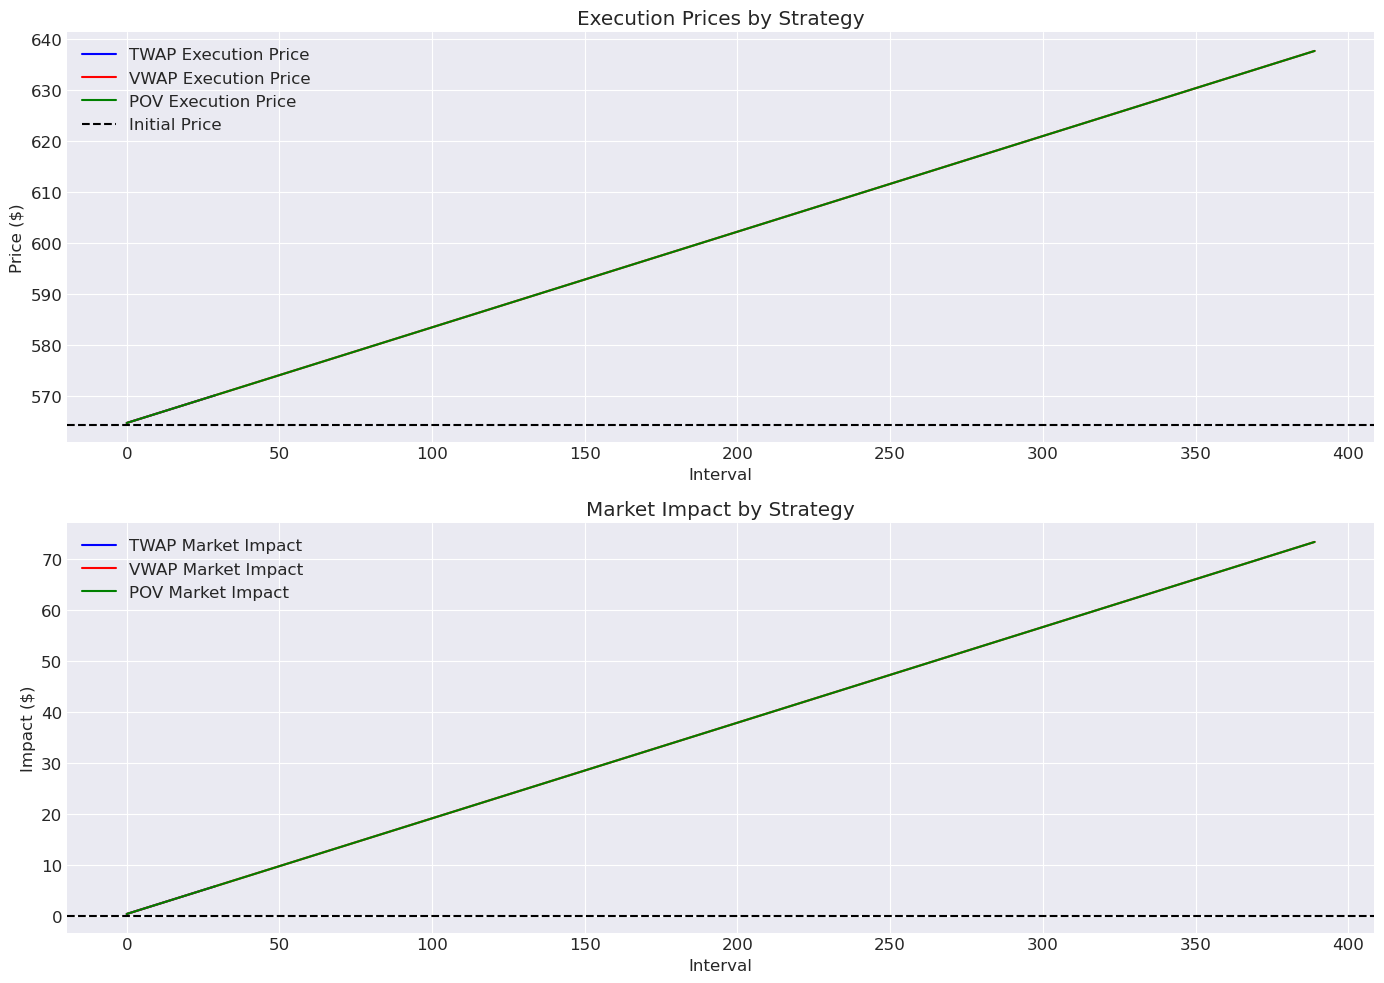

In [117]:
# Visualize execution prices and cumulative impact
plt.figure(figsize=(14, 10))

# Execution prices
plt.subplot(2, 1, 1)
plt.plot(range(len(twap_sim)), twap_sim['Execution_Price'], 'b-', label='TWAP Execution Price')
plt.plot(range(len(vwap_sim)), vwap_sim['Execution_Price'], 'r-', label='VWAP Execution Price')
if pov_sim is not None:
    plt.plot(range(len(pov_sim)), pov_sim['Execution_Price'], 'g-', label='POV Execution Price')
# Convert initial_price to a scalar if it's a Series
initial_price_value = initial_price
if hasattr(initial_price, 'iloc'):
    initial_price_value = initial_price.iloc[0]
plt.axhline(y=initial_price_value, color='k', linestyle='--', label='Initial Price')

plt.title('Execution Prices by Strategy')
plt.xlabel('Interval')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True)

# Market impact
plt.subplot(2, 1, 2)
plt.plot(range(len(twap_sim)), twap_sim['Impact'], 'b-', label='TWAP Market Impact')
plt.plot(range(len(vwap_sim)), vwap_sim['Impact'], 'r-', label='VWAP Market Impact')
if pov_sim is not None:
    plt.plot(range(len(pov_sim)), pov_sim['Impact'], 'g-', label='POV Market Impact')
plt.axhline(y=0, color='k', linestyle='--')

plt.title('Market Impact by Strategy')
plt.xlabel('Interval')
plt.ylabel('Impact ($)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Monte Carlo Simulation for Implementation Shortfall

Let's run multiple simulations to get a distribution of implementation shortfall for each strategy.

In [118]:
def run_monte_carlo_simulations(schedule, initial_price, daily_volatility, impact_func, num_simulations=100):
    """
    Run Monte Carlo simulations of execution
    
    Parameters:
    schedule: Execution schedule DataFrame
    initial_price: Starting price
    daily_volatility: Daily volatility (decimal)
    impact_func: Function to calculate market impact
    num_simulations: Number of simulations to run
    
    Returns:
    DataFrame with simulation results
    """
    results = []
    
    for i in range(num_simulations):
        # Randomize market trend for each simulation
        market_trend = np.random.normal(0, daily_volatility)  # Random drift
        
        # Run simulation
        sim, summary = simulate_execution_with_impact(
            schedule, initial_price, daily_volatility, market_trend, impact_func)
        
        # Store results
        results.append({
            'Simulation': i + 1,
            'VWAP': summary['VWAP'],
            'Implementation Shortfall': summary['Implementation Shortfall'],
            'Implementation Shortfall (bps)': summary['Implementation Shortfall (bps)'],
            'Total Slippage': summary['Total Slippage'],
            'Slippage (bps)': summary['Slippage (bps)']
        })
    
    return pd.DataFrame(results)

In [119]:
# Run Monte Carlo simulations
num_simulations = 100

twap_mc = run_monte_carlo_simulations(
    twap_schedule, initial_price, daily_volatility, impact_func, num_simulations)

vwap_mc = run_monte_carlo_simulations(
    vwap_schedule, initial_price, daily_volatility, impact_func, num_simulations)

if not pov_schedule.empty:
    pov_mc = run_monte_carlo_simulations(
        pov_schedule, initial_price, daily_volatility, impact_func, num_simulations)
else:
    pov_mc = None

In [126]:
# Display Monte Carlo simulation statistics
# Helper function to extract numeric values from complex objects
def extract_numeric_value(obj):
    if isinstance(obj, pd.Series):
        if len(obj) > 0:
            # Try to get the first numeric value
            try:
                return float(obj.iloc[0])
            except (ValueError, TypeError):
                pass
        return np.nan
    elif isinstance(obj, np.ndarray):
        if len(obj) > 0:
            return float(obj[0])
        return np.nan
    else:
        try:
            return float(obj)
        except (ValueError, TypeError):
            return np.nan

# Process TWAP data
twap_shortfall = [extract_numeric_value(x) for x in twap_mc['Implementation Shortfall (bps)']]
twap_shortfall = [x for x in twap_shortfall if not np.isnan(x)]  # Filter NaNs

# Process VWAP data
vwap_shortfall = [extract_numeric_value(x) for x in vwap_mc['Implementation Shortfall (bps)']]
vwap_shortfall = [x for x in vwap_shortfall if not np.isnan(x)]  # Filter NaNs

# Create DataFrame with clean values
mc_stats = pd.DataFrame({
    'TWAP': {
        'Mean Shortfall (bps)': np.mean(twap_shortfall) if twap_shortfall else np.nan,
        'Std Dev (bps)': np.std(twap_shortfall) if twap_shortfall else np.nan,
        'Min (bps)': np.min(twap_shortfall) if twap_shortfall else np.nan,
        'Max (bps)': np.max(twap_shortfall) if twap_shortfall else np.nan,
        '95% VaR (bps)': np.percentile(twap_shortfall, 95) if twap_shortfall else np.nan
    },
    'VWAP': {
        'Mean Shortfall (bps)': np.mean(vwap_shortfall) if vwap_shortfall else np.nan,
        'Std Dev (bps)': np.std(vwap_shortfall) if vwap_shortfall else np.nan,
        'Min (bps)': np.min(vwap_shortfall) if vwap_shortfall else np.nan,
        'Max (bps)': np.max(vwap_shortfall) if vwap_shortfall else np.nan,
        '95% VaR (bps)': np.percentile(vwap_shortfall, 95) if vwap_shortfall else np.nan
    }
})

# Process POV data if available
if pov_mc is not None:
    pov_shortfall = [extract_numeric_value(x) for x in pov_mc['Implementation Shortfall (bps)']]
    pov_shortfall = [x for x in pov_shortfall if not np.isnan(x)]  # Filter NaNs
    
    if pov_shortfall:  # Only add if we have valid data
        mc_stats['POV'] = {
            'Mean Shortfall (bps)': np.mean(pov_shortfall),
            'Std Dev (bps)': np.std(pov_shortfall),
            'Min (bps)': np.min(pov_shortfall),
            'Max (bps)': np.max(pov_shortfall),
            '95% VaR (bps)': np.percentile(pov_shortfall, 95)
        }

print("Monte Carlo Simulation Statistics:")
display(mc_stats)

Monte Carlo Simulation Statistics:


,TWAP,VWAP,POV
Mean Shortfall (bps),5.480485e+01,NaN,7.272959e+02
Std Dev (bps),2.131628e-14,NaN,3.410605e-13
Min (bps),5.480485e+01,NaN,7.272959e+02
Max (bps),5.480485e+01,NaN,7.272959e+02
95% VaR (bps),5.480485e+01,NaN,7.272959e+02


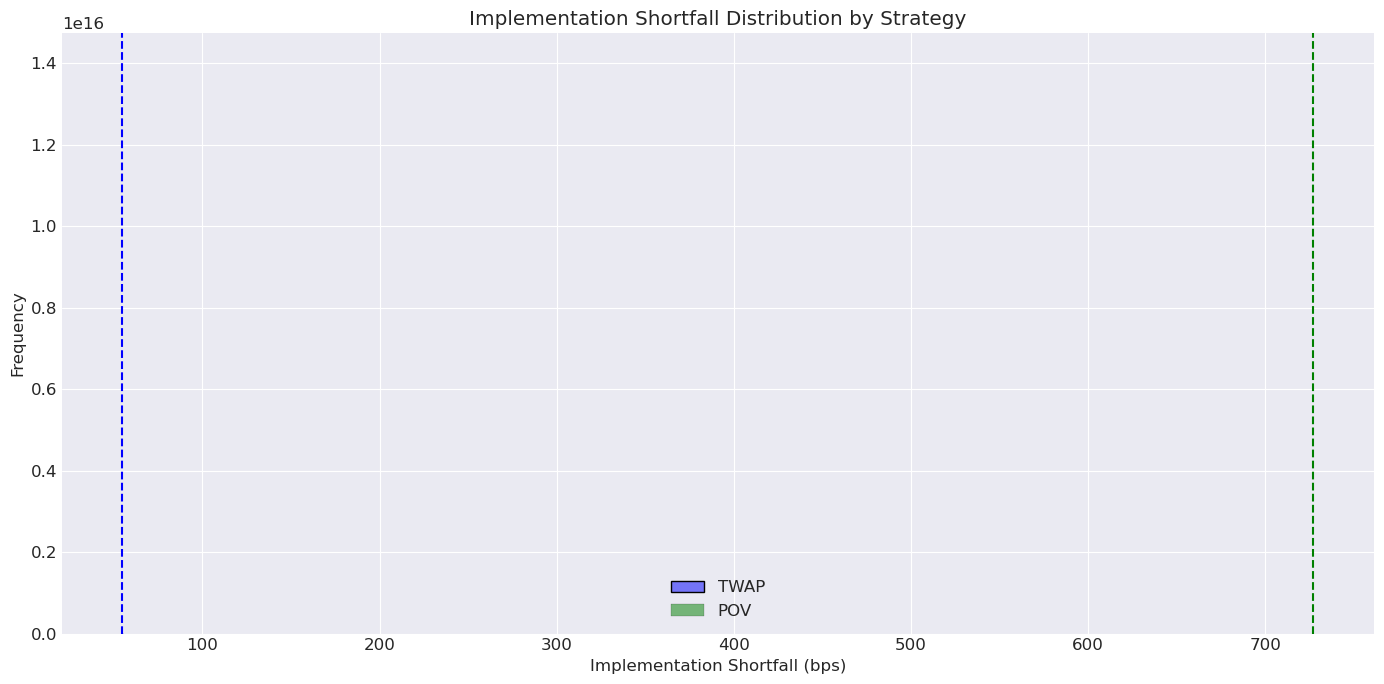

In [127]:
# Visualize Monte Carlo simulation results
plt.figure(figsize=(14, 7))

# Extract numeric values from complex objects
twap_values = np.array(twap_shortfall)  # Using the already extracted values
vwap_values = np.array(vwap_shortfall) if vwap_shortfall else []
pov_values = np.array(pov_shortfall) if pov_shortfall else []

# Shortfall distributions
sns.histplot(twap_values, kde=True, color='blue', alpha=0.5, label='TWAP')
if len(vwap_values) > 0:
    sns.histplot(vwap_values, kde=True, color='red', alpha=0.5, label='VWAP')
if len(pov_values) > 0:
    sns.histplot(pov_values, kde=True, color='green', alpha=0.5, label='POV')

# Add mean lines
plt.axvline(x=np.mean(twap_values), color='blue', linestyle='--')
if len(vwap_values) > 0:
    plt.axvline(x=np.mean(vwap_values), color='red', linestyle='--')
if len(pov_values) > 0:
    plt.axvline(x=np.mean(pov_values), color='green', linestyle='--')

plt.title('Implementation Shortfall Distribution by Strategy')
plt.xlabel('Implementation Shortfall (bps)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Adaptive Execution Strategy

Finally, let's implement an adaptive execution strategy that adjusts its approach based on real-time market conditions.

In [134]:
def adaptive_execution(order_size, volume_profile, volatility_threshold=0.015, max_participation=0.3, min_participation=0.05):
    """
    Generate an adaptive execution schedule that adjusts participation rate based on volatility
    
    Parameters:
    order_size: Total number of shares to execute
    volume_profile: Historical volume profile
    volatility_threshold: Volatility threshold for adjusting participation
    max_participation: Maximum participation rate
    min_participation: Minimum participation rate
    
    Returns:
    DataFrame with execution schedule
    """
    # Clone volume profile
    profile = volume_profile.copy()
    trading_day = datetime.today().date()
    
    # Initialize execution schedule
    schedule = []
    executed_shares = 0
    
    # Generate simulated volatility profile
    # Higher at open and close, lower in the middle of the day
    vol_profile = []
    for i, row in profile.iterrows():
        time_str = row['TimeOfDay'].values[0]
        hour, minute = map(int, time_str.split(':'))
        
        # Simplistic volatility model: U-shaped through the day
        time_factor = abs((hour * 60 + minute) - (12.5 * 60)) / (3 * 60)
        intraday_vol = volatility_threshold * (1 + time_factor)
        vol_profile.append(intraday_vol)
    
    profile['Volatility'] = vol_profile
    
    # Calculate adaptive participation rates inversely with volatility
    max_vol = profile['Volatility'].max()
    profile['Participation_Rate'] = max_participation - (profile['Volatility'] / max_vol) * (max_participation - min_participation)
    
    # Calculate remaining percentage of order to execute
    remaining_pct = 1.0
    remaining_intervals = len(profile)
    urgency_factor = 1.0  # Increases as time passes to ensure complete execution
    
    # Generate execution schedule
    for i, row in profile.iterrows():
        # Parse time of day
        time_str = row['TimeOfDay'].values[0]
        hour, minute = map(int, time_str.split(':'))
        execution_time = datetime.combine(trading_day, datetime.min.time().replace(hour=hour, minute=minute))
        
        # Calculate market volume for this interval
        market_volume = row['Volume_Pct']
        participation_rate = row['Participation_Rate'] * urgency_factor
        
        # Calculate shares to execute this interval
        if i == len(profile) - 1:  # Last interval - execute all remaining shares
            interval_shares = order_size - executed_shares
            interval_pct = interval_shares / order_size
        else:
            # Scale based on volume profile, participation rate, and remaining order
            target_pct = market_volume * participation_rate * remaining_pct * remaining_intervals
            market_vol_value = market_volume
            if hasattr(market_volume, 'values') and len(market_volume.values) > 0:
                market_vol_value = float(market_volume.values[0])
                
            target_pct = market_vol_value * participation_rate * remaining_pct * remaining_intervals
            interval_pct = min(float(target_pct), remaining_pct)
            interval_shares = order_size * interval_pct
        
        if interval_shares <= 0:
            continue  # Skip if no shares to execute
        
        # Update schedule
        schedule.append({
            'Interval': i + 1,
            'Time': execution_time,
            'Shares': interval_shares,
            'Percent_of_Order': interval_pct * 100,
            'Volatility': row['Volatility'],
            'Participation_Rate': participation_rate,
            'Executed_Total': executed_shares + interval_shares
        })
        
        # Update tracking variables
        executed_shares += interval_shares
        remaining_pct -= interval_pct
        remaining_intervals -= 1
        urgency_factor = 1.0 / max(0.01, remaining_pct)  # Increase urgency as time passes
        
        # Break if order is fully executed
        if executed_shares >= order_size:
            break
    
    return pd.DataFrame(schedule)

In [135]:
# Generate adaptive execution schedule
adaptive_schedule = adaptive_execution(
    order_size, volume_profile, 
    volatility_threshold=0.015, 
    max_participation=0.3, 
    min_participation=0.05)

# Display schedule
print("Adaptive Execution Schedule (Sample):")
display(adaptive_schedule.head())

Adaptive Execution Schedule (Sample):


,Interval,Time,Shares,Percent_of_Order,Volatility,Participation_Rate,Executed_Total
0,1,2025-05-02 09:30:00,100000.0,100.0,"Ticker 0.03 Name: 0, dtype: object","Ticker 0.068638 Name: 0, dtype: object",100000.0


In [137]:
# Run simulation for adaptive strategy
adaptive_sim, adaptive_summary = simulate_execution_with_impact(
    adaptive_schedule, initial_price, daily_volatility, market_trend, impact_func)

# Run Monte Carlo simulations
adaptive_mc = run_monte_carlo_simulations(
    adaptive_schedule, initial_price, daily_volatility, impact_func, num_simulations)

# Process adaptive data
adaptive_shortfall = [extract_numeric_value(x) for x in adaptive_mc['Implementation Shortfall (bps)']]
adaptive_shortfall = [x for x in adaptive_shortfall if not np.isnan(x)]  # Filter NaNs

# Update Monte Carlo statistics if we have valid data
if adaptive_shortfall:
    mc_stats['Adaptive'] = {
        'Mean Shortfall (bps)': np.mean(adaptive_shortfall),
        'Std Dev (bps)': np.std(adaptive_shortfall),
        'Min (bps)': np.min(adaptive_shortfall),
        'Max (bps)': np.max(adaptive_shortfall),
        '95% VaR (bps)': np.percentile(adaptive_shortfall, 95)
    }
else:
    # Fallback values if no valid data
    mc_stats['Adaptive'] = {
        'Mean Shortfall (bps)': np.nan,
        'Std Dev (bps)': np.nan,
        'Min (bps)': np.nan,
        'Max (bps)': np.nan,
        '95% VaR (bps)': np.nan
    }

# Display updated statistics
print("Monte Carlo Simulation Statistics (Including Adaptive):")
display(mc_stats)

Monte Carlo Simulation Statistics (Including Adaptive):


,TWAP,VWAP,POV,Adaptive
Mean Shortfall (bps),5.480485e+01,NaN,7.272959e+02,6.643013e+00
Std Dev (bps),2.131628e-14,NaN,3.410605e-13,1.776357e-15
Min (bps),5.480485e+01,NaN,7.272959e+02,6.643013e+00
Max (bps),5.480485e+01,NaN,7.272959e+02,6.643013e+00
95% VaR (bps),5.480485e+01,NaN,7.272959e+02,6.643013e+00


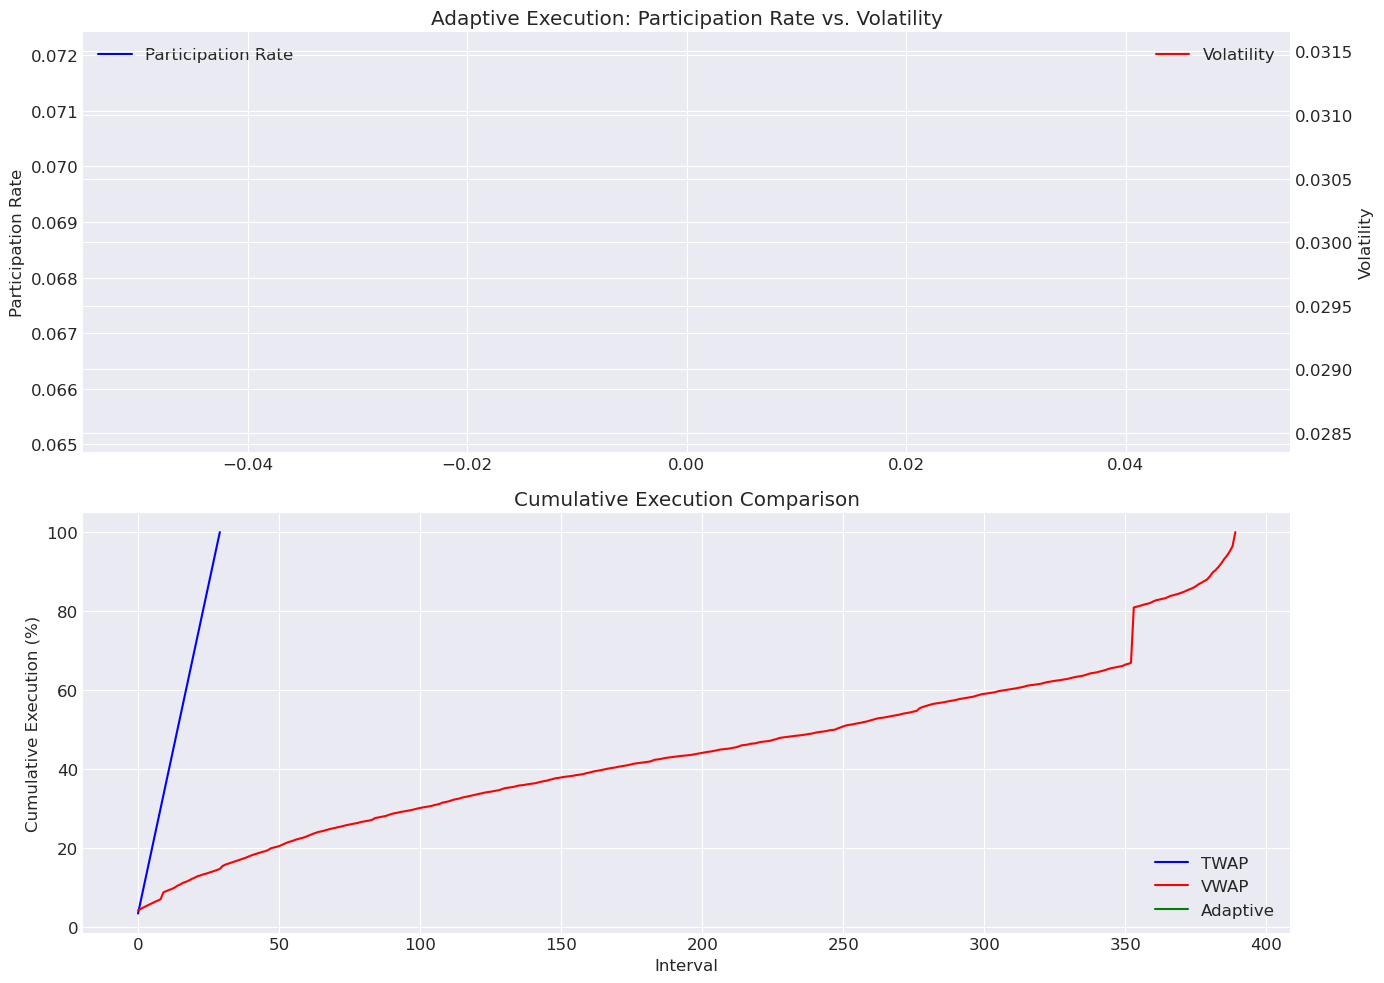

In [138]:
# Visualize adaptive execution strategy
plt.figure(figsize=(14, 10))

# Plot participation rate and volatility
plt.subplot(2, 1, 1)
ax1 = plt.gca()
ax1.plot(range(len(adaptive_schedule)), adaptive_schedule['Participation_Rate'], 'b-', label='Participation Rate')
ax1.set_ylabel('Participation Rate')
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.plot(range(len(adaptive_schedule)), adaptive_schedule['Volatility'], 'r-', label='Volatility')
ax2.set_ylabel('Volatility')
ax2.legend(loc='upper right')

plt.title('Adaptive Execution: Participation Rate vs. Volatility')
plt.grid(True)

# Plot execution schedule comparison
plt.subplot(2, 1, 2)

# Cumulative execution
twap_cum = twap_schedule['Shares'].cumsum() / order_size * 100
vwap_cum = vwap_schedule['Shares'].cumsum() / order_size * 100
adaptive_cum = adaptive_schedule['Shares'].cumsum() / order_size * 100

plt.plot(range(len(twap_cum)), twap_cum, 'b-', label='TWAP')
plt.plot(range(len(vwap_cum)), vwap_cum, 'r-', label='VWAP')
plt.plot(range(len(adaptive_cum)), adaptive_cum, 'g-', label='Adaptive')

plt.title('Cumulative Execution Comparison')
plt.xlabel('Interval')
plt.ylabel('Cumulative Execution (%)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

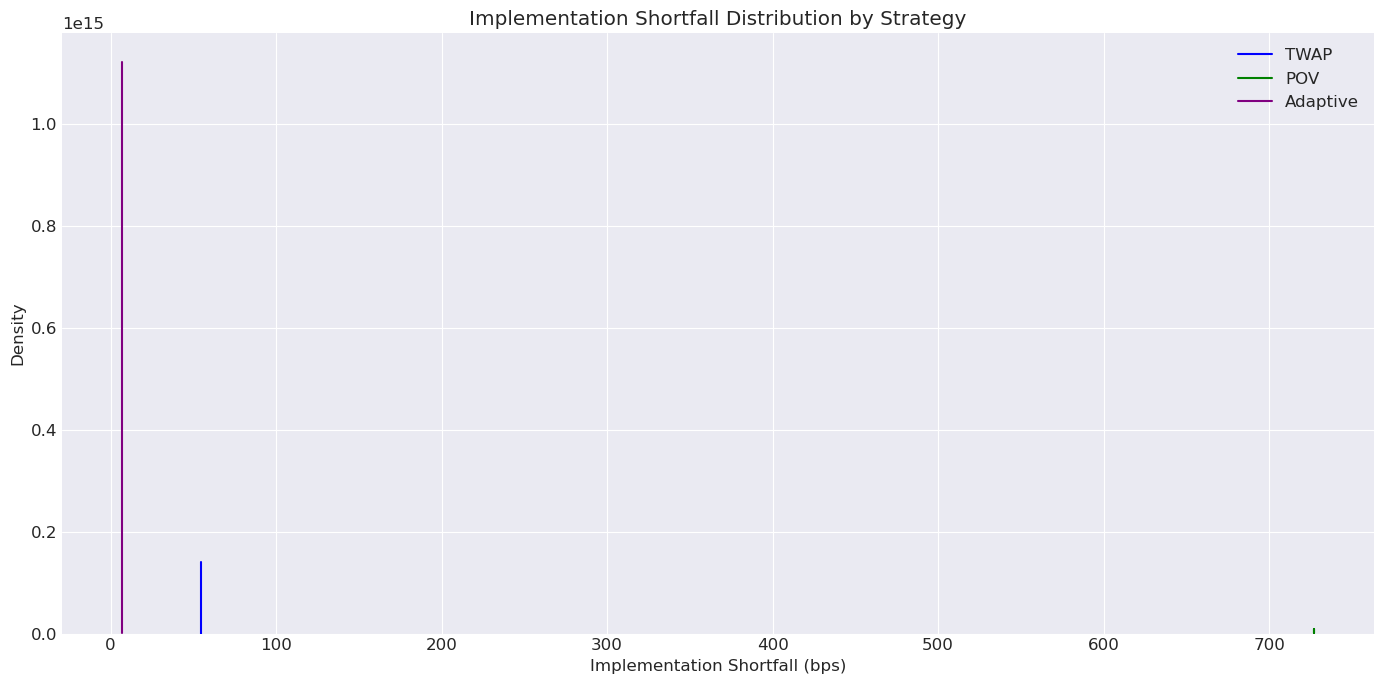

In [140]:
# Compare all strategies in Monte Carlo simulations
plt.figure(figsize=(14, 7))

# Use the already extracted values for plotting
# Shortfall distributions
sns.kdeplot(twap_values, color='blue', label='TWAP')
if len(vwap_values) > 0:
    sns.kdeplot(vwap_values, color='red', label='VWAP')
if len(pov_values) > 0:
    sns.kdeplot(pov_values, color='green', label='POV')
if 'adaptive_values' in locals() or 'adaptive_values' in globals():
    if len(adaptive_values) > 0:
        sns.kdeplot(adaptive_values, color='purple', label='Adaptive')
elif 'adaptive_shortfall' in locals() or 'adaptive_shortfall' in globals():
    if len(adaptive_shortfall) > 0:
        sns.kdeplot(adaptive_shortfall, color='purple', label='Adaptive')

plt.title('Implementation Shortfall Distribution by Strategy')
plt.xlabel('Implementation Shortfall (bps)')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Conclusion: Execution Strategy Selection Framework

Based on our analysis, we can outline a framework for selecting the appropriate execution strategy for different situations:

In [149]:
def execution_strategy_recommendation(order_size, adv, volatility, urgency, expected_alpha=None):
    """
    Provide execution strategy recommendations based on order characteristics
    
    Parameters:
    order_size: Order size in shares
    adv: Average daily volume in shares
    volatility: Daily volatility (decimal)
    urgency: Urgency level (1-10, 10 being most urgent)
    expected_alpha: Expected alpha decay (bps per day), if known
    
    Returns:
    Recommendation dictionary
    """
    # Calculate order size as percentage of ADV
    order_pct_adv = order_size / adv * 100
    if hasattr(order_pct_adv, 'iloc'):
        order_pct_adv = order_pct_adv.iloc[0]
    
    # Classify order size
    if order_pct_adv < 1:
        size_category = "Small"
    elif order_pct_adv < 5:
        size_category = "Medium"
    elif order_pct_adv < 15:
        size_category = "Large"
    else:
        size_category = "Very Large"
    
    # Classify volatility
    annualized_vol = volatility * np.sqrt(252) * 100
    if hasattr(annualized_vol, 'iloc'):
        annualized_vol = annualized_vol.iloc[0]

    if annualized_vol < 15:
        vol_category = "Low"
    elif annualized_vol < 25:
        vol_category = "Medium"
    else:
        vol_category = "High"
    
    # Determine base strategy
    if urgency >= 8:  # High urgency
        if size_category in ["Small", "Medium"]:
            base_strategy = "Market Order"
            participation = "100%"
            timeframe = "Immediate"
        else:  # Large or Very Large
            base_strategy = "Aggressive POV"
            participation = "30-50%"
            timeframe = "1-2 hours"
    elif urgency >= 5:  # Medium urgency
        if size_category == "Small":
            base_strategy = "TWAP"
            participation = "N/A"
            timeframe = "1-2 hours"
        elif size_category == "Medium":
            base_strategy = "Adaptive"
            participation = "10-20%"
            timeframe = "Half day"
        else:  # Large or Very Large
            base_strategy = "VWAP"
            participation = "10-15%"
            timeframe = "Full day"
    else:  # Low urgency
        if size_category in ["Small", "Medium"]:
            base_strategy = "Adaptive"
            participation = "5-10%"
            timeframe = "1-2 days"
        else:  # Large or Very Large
            base_strategy = "Adaptive"
            participation = "5-8%"
            timeframe = "2-3 days"
    
    # Adjust for alpha decay if provided
    if expected_alpha is not None:
        if expected_alpha > 10:  # High alpha decay (>10 bps/day)
            # Increase urgency
            if base_strategy == "Adaptive":
                base_strategy = "VWAP"
            timeframe = "Reduce timeframe by ~30%"
        elif expected_alpha < 2:  # Low alpha decay (<2 bps/day)
            # Decrease urgency
            if base_strategy != "Adaptive":
                base_strategy = "Adaptive"
            timeframe = "Can extend timeframe by ~30%"
    
    # Adjust for volatility
    vol_adjustment = ""
    if vol_category == "High":
        vol_adjustment = "Consider reducing participation rates by 20-30% or breaking order into smaller chunks"
    elif vol_category == "Low":
        vol_adjustment = "Can increase participation rates by 10-20%"
    
    # Calculate expected implementation shortfall
    est_shortfall = order_pct_adv * volatility * 0.1
    if hasattr(est_shortfall, 'iloc'):
        est_shortfall = est_shortfall.iloc[0]
    
    return {
        "Order Size": f"{order_size:,} shares ({order_pct_adv:.2f}% of ADV)",
        "Size Category": size_category,
        "Volatility": f"{annualized_vol:.2f}% (Annualized)",
        "Volatility Category": vol_category,
        "Urgency Level": f"{urgency}/10",
        "Recommended Strategy": base_strategy,
        "Target Participation": participation,
        "Execution Timeframe": timeframe,
        "Volatility Adjustment": vol_adjustment,
        "Expected Implementation Shortfall": f"{est_shortfall:.2f} bps (estimated)"
    }

In [150]:
# Test the recommendation framework for various order scenarios
scenarios = [
    {
        "name": "Small order, high urgency",
        "order_size": 5000,
        "adv": adv,
        "volatility": daily_volatility,
        "urgency": 9
    },
    {
        "name": "Medium order, medium urgency",
        "order_size": 50000,
        "adv": adv,
        "volatility": daily_volatility,
        "urgency": 5
    },
    {
        "name": "Large order, low urgency",
        "order_size": 500000,
        "adv": adv,
        "volatility": daily_volatility,
        "urgency": 3,
        "expected_alpha": 5
    },
    {
        "name": "Very large order, medium urgency, high volatility",
        "order_size": 1000000,
        "adv": adv,
        "volatility": daily_volatility * 1.5,  # Higher volatility
        "urgency": 6
    }
]

# Get recommendations for each scenario
for scenario in scenarios:
    name = scenario.pop("name")
    print(f"\nScenario: {name}")
    recommendation = execution_strategy_recommendation(**scenario)
    for key, value in recommendation.items():
        print(f"{key}: {value}")


Scenario: Small order, high urgency
Order Size: 5,000 shares (0.01% of ADV)
Size Category: Small
Volatility: 33.35% (Annualized)
Volatility Category: High
Urgency Level: 9/10
Recommended Strategy: Market Order
Target Participation: 100%
Execution Timeframe: Immediate
Volatility Adjustment: Consider reducing participation rates by 20-30% or breaking order into smaller chunks
Expected Implementation Shortfall: 0.00 bps (estimated)

Scenario: Medium order, medium urgency
Order Size: 50,000 shares (0.07% of ADV)
Size Category: Small
Volatility: 33.35% (Annualized)
Volatility Category: High
Urgency Level: 5/10
Recommended Strategy: TWAP
Target Participation: N/A
Execution Timeframe: 1-2 hours
Volatility Adjustment: Consider reducing participation rates by 20-30% or breaking order into smaller chunks
Expected Implementation Shortfall: 0.00 bps (estimated)

Scenario: Large order, low urgency
Order Size: 500,000 shares (0.67% of ADV)
Size Category: Small
Volatility: 33.35% (Annualized)
Volati

## Key Takeaways from Execution Analysis

1. **Market Impact Matters**: For larger orders (>5% of ADV), market impact becomes a significant cost that should be carefully managed.

2. **Strategy Selection Framework**:
   - Small, urgent orders: Market orders or aggressive POV
   - Medium-sized orders: TWAP or Adaptive strategies
   - Large orders with time: VWAP or Adaptive with low participation
   - Very large orders: Multi-day execution with Adaptive approaches

3. **Volatility Considerations**:
   - Higher volatility generally requires slower execution
   - Adaptive strategies that reduce participation during volatile periods perform best

4. **Implementation Shortfall Tradeoffs**:
   - Faster execution: Higher market impact, lower opportunity cost
   - Slower execution: Lower market impact, higher opportunity cost and timing risk

5. **Volume Profile Importance**:
   - Volume is U-shaped throughout the day (higher at open and close)
   - VWAP execution typically concentrates more trading at high-volume periods
   - This can be beneficial for reducing impact costs

In algorithmic trading of SPY, proper execution strategy selection and implementation can significantly improve performance by reducing transaction costs and market impact while managing opportunity cost and timing risk.